<a href="https://colab.research.google.com/github/Anubhav-maurya6386/INTRANSHIP_TASK/blob/main/Level3Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("/content/churn-bigml-80.csv")
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
df = df.drop(['State'], axis=1)  # if present

In [4]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [5]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [8]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(rf, param_grid, cv=5, scoring='f1')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}


In [9]:
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy')
print("Cross-validation Accuracy:", cv_scores.mean())

Cross-validation Accuracy: 0.9519868457111537


In [10]:
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.949438202247191
              precision    recall  f1-score   support

       False       0.95      1.00      0.97       455
        True       0.98      0.67      0.80        79

    accuracy                           0.95       534
   macro avg       0.96      0.83      0.88       534
weighted avg       0.95      0.95      0.95       534



In [11]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

                   Feature  Importance
5        Total day minutes    0.143595
7         Total day charge    0.136831
17  Customer service calls    0.105849
2       International plan    0.096580
10        Total eve charge    0.075640
8        Total eve minutes    0.063425
15        Total intl calls    0.051314
16       Total intl charge    0.048247
14      Total intl minutes    0.043785
13      Total night charge    0.036345
11     Total night minutes    0.034756
6          Total day calls    0.029868
0           Account length    0.029328
12       Total night calls    0.028965
4    Number vmail messages    0.026091
9          Total eve calls    0.024986
3          Voice mail plan    0.019277
1                Area code    0.005120


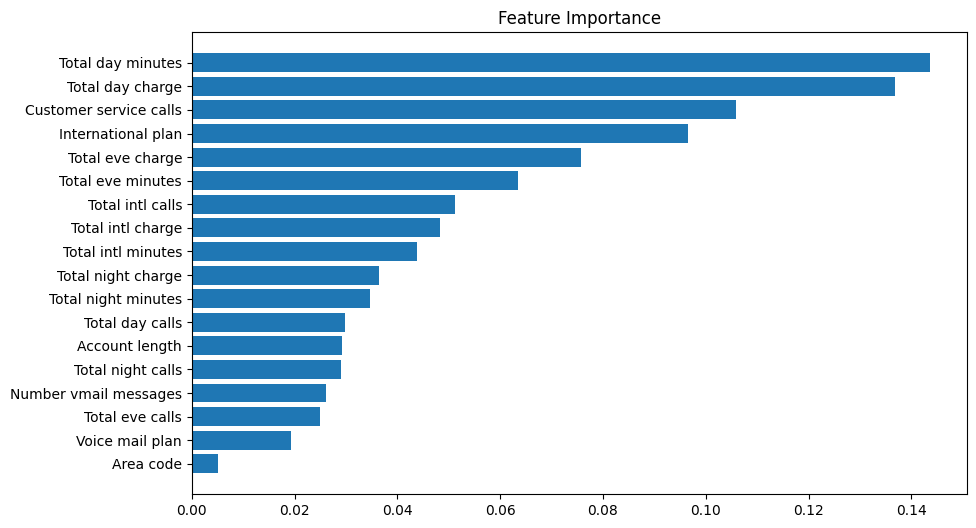

In [12]:
plt.figure(figsize=(10,6))
plt.barh(importance['Feature'], importance['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()